### Predicting PCOS using Ultrasound images
DATA INFORMATION #TODO

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

In [2]:
batch_size = 64
n_epochs = 5

### Load data

In [3]:
data = datasets.ImageFolder(
    root="pcos_dataset",
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((128, 128)),
        transforms.Grayscale(num_output_channels=1),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1)),
        transforms.RandomVerticalFlip(p=0.5),
    ]
),
    
)

#Split into training and testing subsets
train_indices, test_indices = train_test_split(
    range(len(data)),
    test_size = 0.3,
    shuffle=True
)

In [26]:
print("Classes found:", data.classes)
print("Class to index mapping:", data.class_to_idx)

Classes found: ['infected', 'noninfected']
Class to index mapping: {'infected': 0, 'noninfected': 1}


In [20]:
train_data = Subset(data, train_indices)
test_data = Subset(data, test_indices)

In [ ]:
#Normalize 
u=torch.zeros(1) #Grayscale, so 1 channel
u2=torch.zeros(1)
n=0
for image, _ in train_data:
    u+=image.mean([1,2])
    u2+= (image**2).mean([1,2])
    n+=1
u/=n
u2/=n
s=(u2-u**2).sqrt()

normalization = transforms.Normalize(u.tolist(), s.tolist())
data.transform.transforms.append(normalization)

## Create DataLoaders

In [6]:
train_loader=DataLoader(
    train_data,
    batch_size = batch_size,
    shuffle=True 
)

test_loader=DataLoader(
    test_data,
    batch_size = batch_size,
    shuffle=True 
)

## Visualize Data

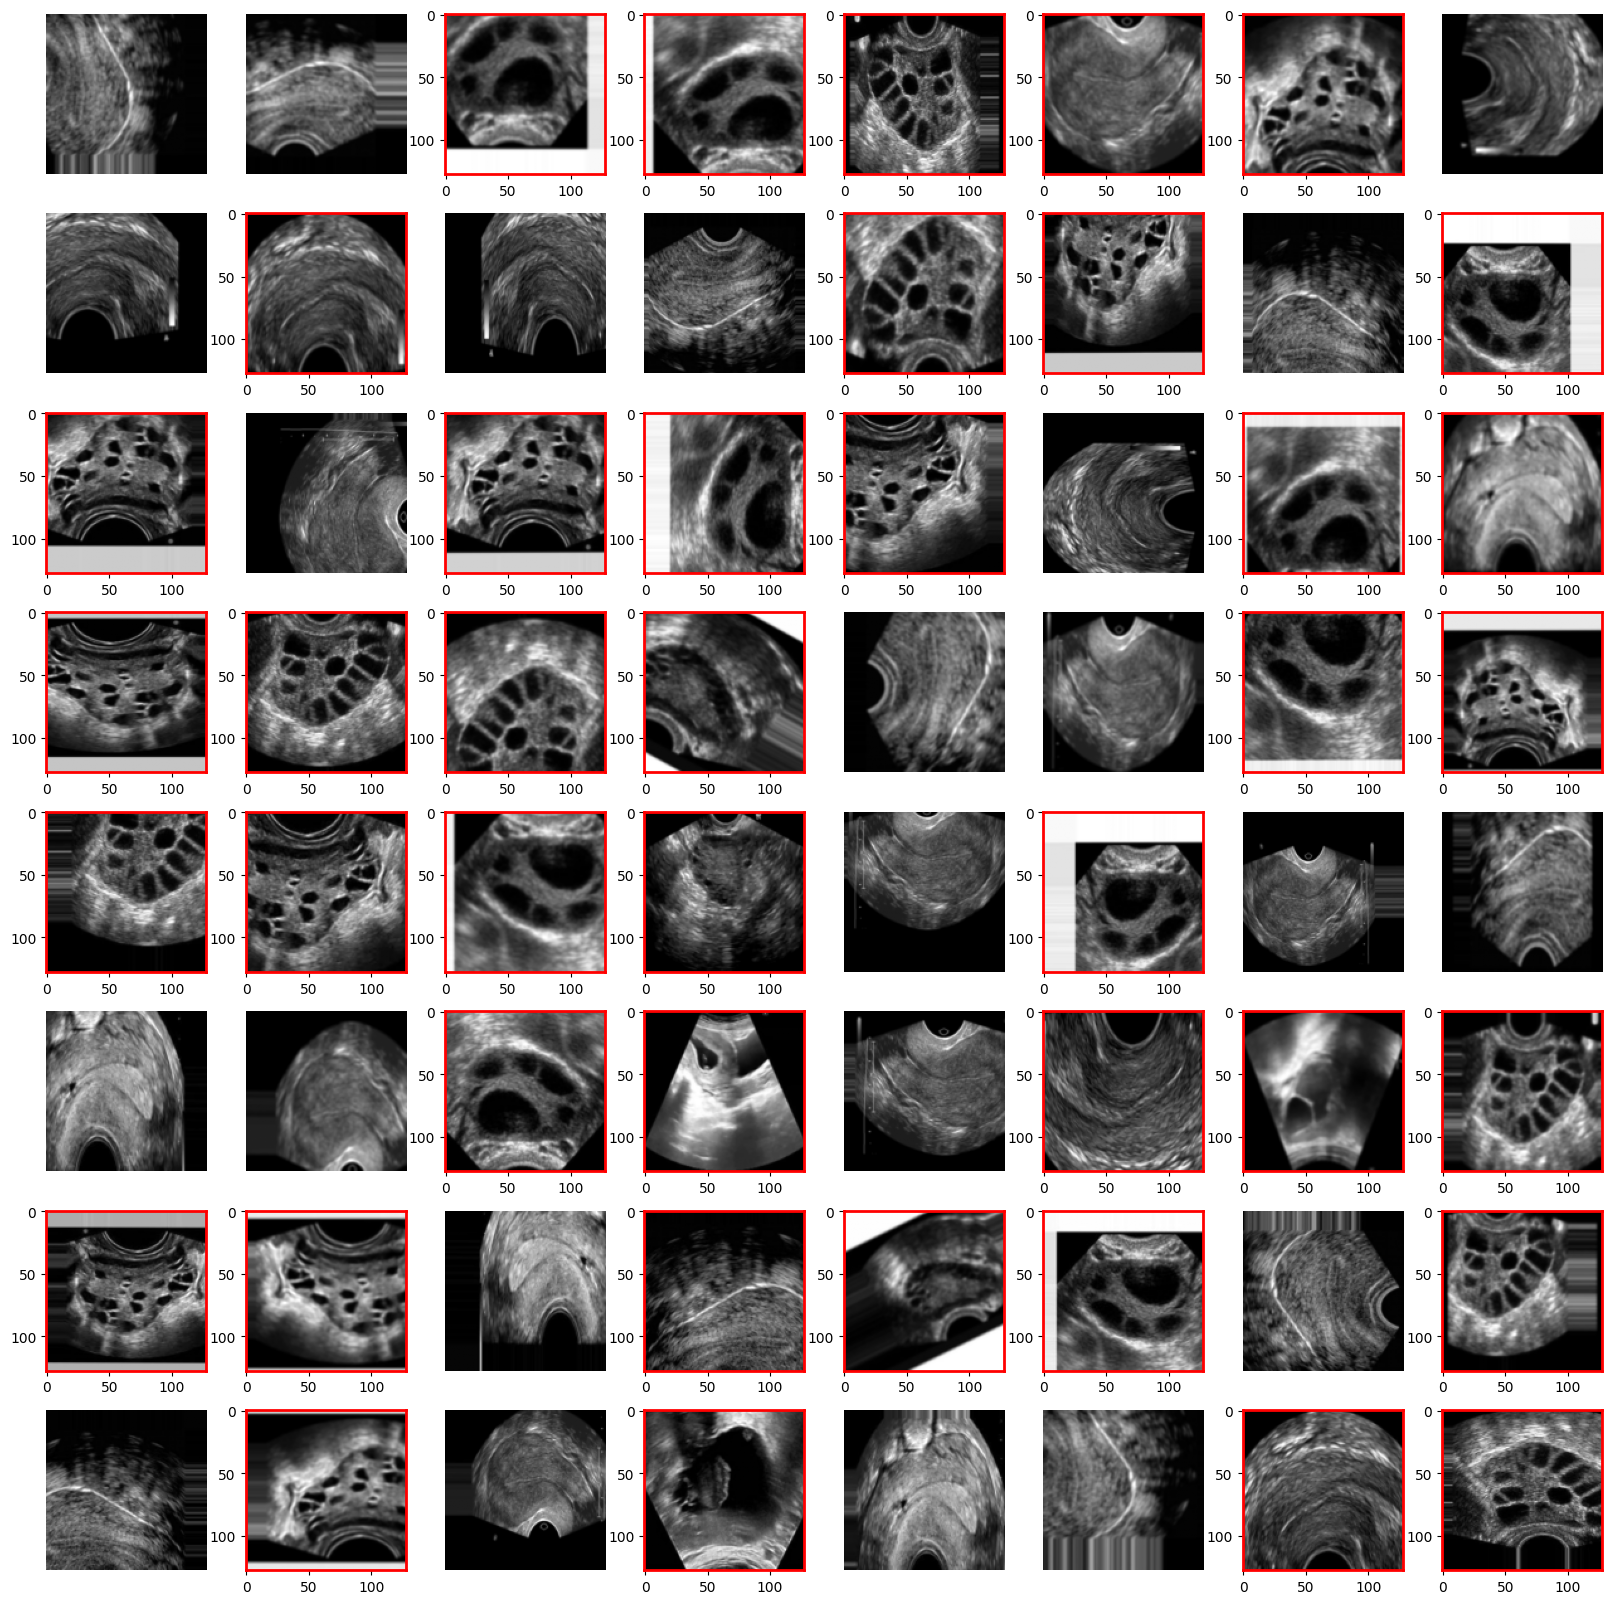

In [7]:
images, labels = next(iter(train_loader)) #Taking one of the batches to visualize
batch_size=images.shape[0] #Number of images in the batch
ncol = int(np.ceil(np.sqrt(batch_size))) #Computing grid size for image display
nrow = int(np.ceil(batch_size/ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(ncol*2, nrow*2)) #Create figure with nrow and ncol of subplots
# Flatten axes array for easy indexing 
ax = ax.flatten()

# Denormalize and plot for visualization
for k in range(batch_size): 
    # Denormalize
    image = (images[k] * s[:, None, None] + u[:, None, None]).cpu()
    image_np = image.squeeze().numpy()  # remove channel dimension for grayscale

    ax[k].imshow(image_np, cmap="gray")
    ax[k].axis("off")  # hide axes ticks by default

    # Highlight PCOS images with red border; the dataset labels them as infected
    if labels[k] == 0:
        for spine in ax[k].spines.values():
            spine.set_linewidth(2)
            spine.set_edgecolor("red")
        ax[k].axis("on")  # show border


plt.tight_layout(pad=0.3)
plt.show()



In [8]:
#Print the size of the image tensors to confirm for use in the model
print(images.shape)

torch.Size([64, 1, 128, 128])


## Model

In [9]:
model = nn.Sequential(
    #Input: 1 channel, each with 128^2 tensor
    #Output: 32 channels each with (128-3+1)^2=126^2 Kernel Size: 3
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
    nn.ReLU(), #ReLU activation function
    #Input: 32 channels each with 126 tensor
    #Output: 32 channels each with (126-3+1)^2 = 124^2 tensor
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
    nn.ReLU(),
    #Dropout
    nn.Dropout(0.25),
    #Input: 32 channels with 124^2 tensor
    #Output: 32 channels with 62^2 tesnor
    nn.MaxPool2d(kernel_size=2),
    #Input: 32 channels with 62^2 tensor
    #Output: 32 channels each with (62-3+1)^2 = 60^2 tensor
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
    nn.ReLU(),
    #Dropout
    nn.Dropout(0.25), #Adding another dropout to reduce overfitting
    #Input: 32 channels with 60^2 tensor
    #Output: 32 channels with 30^2 tensor
    nn.MaxPool2d(kernel_size=2),
    #Input: 32 channels with 30^2 tensor
    #Output: 16 channels with (30-3+1)^2 = 28^2 tensor
    nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3),
    nn.ReLU(),
    #Dropout
    nn.Dropout(0.25),
    #Input: 16 channels with 28^2 tensor
    #Output: 16 channels with 14^2 tensor
    nn.MaxPool2d(kernel_size=2),
    #Input: 16 channels with 14^2 tensor
    #Output: 16*14*14 = 3136
    nn.Flatten(),
    #Fully connected neural network with 1 hidden layer
    nn.Linear(3136, 64),
    nn.ReLU(),
    nn.Dropout(0.5), #Model was extremely overfit, so using dropout to mitigate that
    nn.Linear(64, 1),
    nn.Sigmoid(),
)

In [10]:
model

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (3): ReLU()
  (4): Dropout(p=0.25, inplace=False)
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (7): ReLU()
  (8): Dropout(p=0.25, inplace=False)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1))
  (11): ReLU()
  (12): Dropout(p=0.25, inplace=False)
  (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (14): Flatten(start_dim=1, end_dim=-1)
  (15): Linear(in_features=3136, out_features=64, bias=True)
  (16): ReLU()
  (17): Dropout(p=0.5, inplace=False)
  (18): Linear(in_features=64, out_features=1, bias=True)
  (19): Sigmoid()
)

## Train

In [11]:
#After some testing, found that the model is heavily overfit, so I'm adding noise
noise = 1e-4
model.train()
#Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
loss_fn = nn.BCELoss()

#Training loop
losses = []
for epoch in range(n_epochs):
    for X, y in train_loader:
        optimizer.zero_grad()
        yhat = model(X)
        loss = loss_fn(yhat, y.float().view(-1,1))
        losses.append(loss.item())
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            for m in model:
                if isinstance(m, (nn.Conv2d, nn.Linear)):
                    m.weight.add_(noise*torch.randn_like(m.weight))
    print(losses[-1])

0.289241760969162
0.23824891448020935
0.22156071662902832
0.22263462841510773
0.13574431836605072


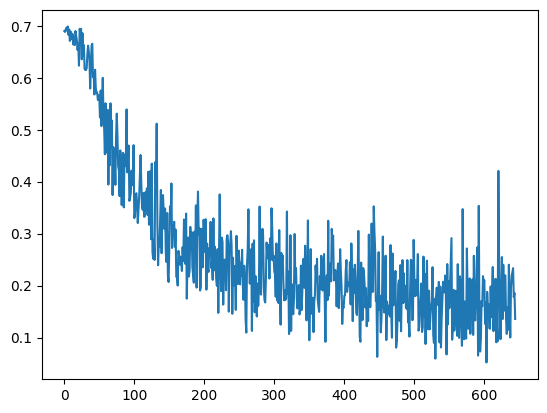

In [12]:
fig, ax = plt.subplots()
ax.plot(losses)

## Evaluate

In [13]:
model.eval()

#Training
ys = []
yhats = []
for X, y in train_loader:
    ys.extend(y.numpy().tolist())
    yhats.extend(model(X).detach().numpy().tolist())
print("Train")
print("Accuracy = ", accuracy_score(ys, np.array(yhats) > 0.5))
print("Precision = ", precision_score(ys, np.array(yhats) > 0.5))
print("Recall = ", recall_score(ys, np.array(yhats) > 0.5))
print("ROC AUC = ", roc_auc_score(ys, yhats))

#Testing
ys = []
yhats = []
for X, y in test_loader:
    ys.extend(y.numpy().tolist())
    yhats.extend(model(X).detach().numpy().tolist())
print("Test")
print("Accuracy = ", accuracy_score(ys, np.array(yhats) > 0.5))
print("Precision = ", precision_score(ys, np.array(yhats) > 0.5))
print("Recall = ", recall_score(ys, np.array(yhats) > 0.5))
print("ROC AUC = ", roc_auc_score(ys, yhats))

Train
Accuracy =  0.9432589718719689
Precision =  0.9196675900277008
Recall =  0.9491137793024585
ROC AUC =  0.9874913785320935
Test
Accuracy =  0.9459841628959276
Precision =  0.9204618345093009
Recall =  0.9553928095872171
ROC AUC =  0.9896535854521078


In [34]:
data2 = datasets.ImageFolder(
    root="combined_data",
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((128, 128)),
        transforms.Grayscale(num_output_channels=1),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1)),
        transforms.RandomVerticalFlip(p=0.5),
    ]
),
)

train_indices, test_indices = train_test_split(
    range(len(data2)),
    test_size = 0.3,
    shuffle=True
)
test_data_2 = Subset(data2, test_indices)

In [35]:
test_loader_2=DataLoader(
    test_data_2,
    batch_size = batch_size,
    shuffle=True 
)

In [36]:
normalization = transforms.Normalize(u.tolist(), s.tolist())
data2.transform.transforms.append(normalization)

In [37]:
#Testing 2
ys_2 = []
yhats_2 = []
for X, y in test_loader_2:
    ys_2.extend(y.numpy().tolist())
    yhats_2.extend(model(X).detach().numpy().tolist())
print("Test")
print("Accuracy = ", accuracy_score(ys_2, np.array(yhats_2) > 0.5))
print("Precision = ", precision_score(ys_2, np.array(yhats_2) > 0.5))
print("Recall = ", recall_score(ys_2, np.array(yhats_2) > 0.5))
print("ROC AUC = ", roc_auc_score(ys_2, yhats_2))

Test
Accuracy =  0.40467937608318894
Precision =  0.0
Recall =  0.0
ROC AUC =  0.4360905653790649


h:\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [38]:
print("Min prediction:", np.min(yhats_2))
print("Max prediction:", np.max(yhats_2))
print("Mean prediction:", np.mean(yhats_2))
print("Predicted positives:", np.sum(np.array(yhats_2) > 0.5))
print("Actual positives:", np.sum(ys_2))

Min prediction: 0.27787479758262634
Max prediction: 0.4636612832546234
Mean prediction: 0.3486450256156756
Predicted positives: 0
Actual positives: 687
